In [2]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Optional advanced
from xgboost import XGBClassifier

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.shape)
print(y.value_counts())

(569, 30)
1    357
0    212
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
lr = LogisticRegression(max_iter=500)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [7]:
def evaluate_model(y_test, y_pred, y_prob):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)
    print("Specificity:", specificity)
    print("Confusion Matrix:\n", cm)

In [8]:
evaluate_model(y_test, y_pred_lr, y_prob_lr)

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
ROC-AUC: 0.9953703703703703
Specificity: 0.9761904761904762
Confusion Matrix:
 [[41  1]
 [ 1 71]]


In [9]:
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [10]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append((name, acc, roc))

    print(f"\n{name}")
    evaluate_model(y_test, y_pred, y_prob)


KNN
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104
ROC-AUC: 0.9788359788359788
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 2 70]]

SVM
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
ROC-AUC: 0.9950396825396826
Specificity: 0.9761904761904762
Confusion Matrix:
 [[41  1]
 [ 1 71]]

Random Forest
Accuracy: 0.9473684210526315
Precision: 0.9583333333333334
Recall: 0.9583333333333334
F1 Score: 0.9583333333333334
ROC-AUC: 0.9915674603174602
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 3 69]]

Gradient Boosting
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9659863945578231
ROC-AUC: 0.9907407407407408
Specificity: 0.9047619047619048
Confusion Matrix:
 [[38  4]
 [ 1 71]]

XGBoost
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
print(results_df.sort_values(by="ROC-AUC", ascending=False))

               Model  Accuracy   ROC-AUC
1                SVM  0.982456  0.995040
2      Random Forest  0.947368  0.991567
3  Gradient Boosting  0.956140  0.990741
4            XGBoost  0.956140  0.990079
0                KNN  0.956140  0.978836


In [12]:
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {scores.mean():.4f}")

KNN CV ROC-AUC: 0.9862
SVM CV ROC-AUC: 0.9938
Random Forest CV ROC-AUC: 0.9855
Gradient Boosting CV ROC-AUC: 0.9863


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost CV ROC-AUC: 0.9902


In [13]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train_scaled, y_train)

print("Best K:", grid.best_params_)

Best K: {'n_neighbors': 9}


In [14]:
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

                 Feature  Importance
22       worst perimeter    0.127879
23            worst area    0.126473
20          worst radius    0.102535
27  worst concave points    0.094829
7    mean concave points    0.090864
3              mean area    0.065631
6         mean concavity    0.062614
2         mean perimeter    0.060533
26       worst concavity    0.042611
0            mean radius    0.035379


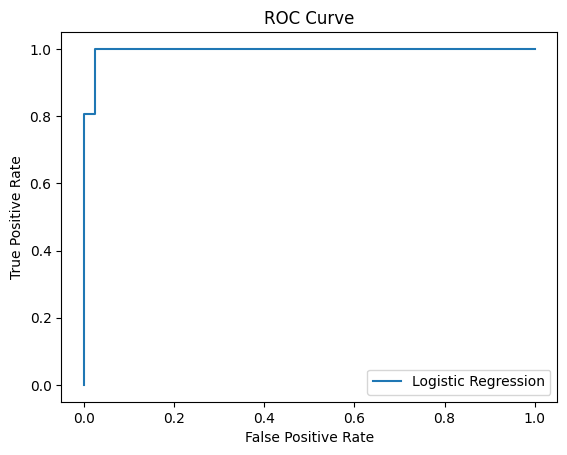

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_train = kmeans.fit_predict(X_train_scaled)
cluster_test = kmeans.predict(X_test_scaled)

# Add as new feature
X_train_k = np.column_stack((X_train_scaled, cluster_train))
X_test_k = np.column_stack((X_test_scaled, cluster_test))

lr.fit(X_train_k, y_train)
y_pred_k = lr.predict(X_test_k)
y_prob_k = lr.predict_proba(X_test_k)[:, 1]

print("\nWith KMeans Feature:")
evaluate_model(y_test, y_pred_k, y_prob_k)


With KMeans Feature:
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
ROC-AUC: 0.9953703703703703
Specificity: 0.9761904761904762
Confusion Matrix:
 [[41  1]
 [ 1 71]]


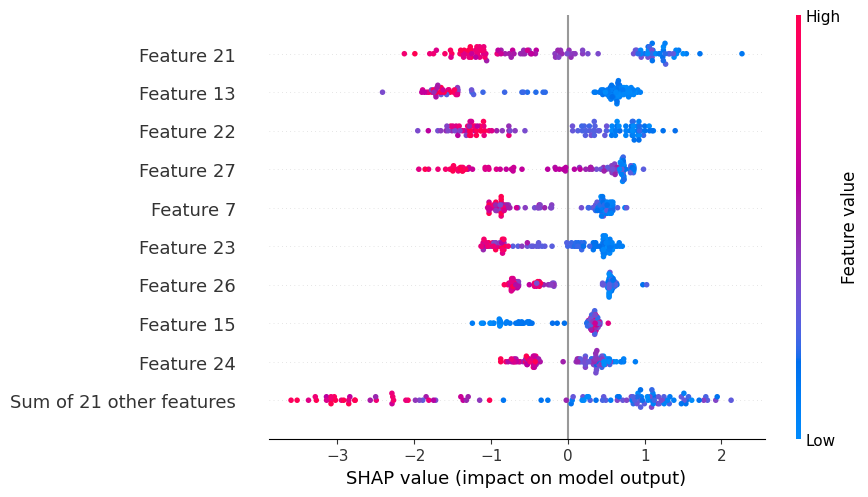

In [17]:
import shap

explainer = shap.Explainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.plots.beeswarm(shap_values)

With SMOTE

In [18]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())

Before SMOTE: 1    285
0    170
Name: count, dtype: int64
After SMOTE: 1    285
0    285
Name: count, dtype: int64


In [19]:
results_smote = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results_smote.append((name, acc, roc))

    print(f"\n{name} (SMOTE)")
    evaluate_model(y_test, y_pred, y_prob)


KNN (SMOTE)
Accuracy: 0.9210526315789473
Precision: 0.9565217391304348
Recall: 0.9166666666666666
F1 Score: 0.9361702127659575
ROC-AUC: 0.9770171957671958
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 6 66]]

SVM (SMOTE)
Accuracy: 0.9736842105263158
Precision: 0.9859154929577465
Recall: 0.9722222222222222
F1 Score: 0.9790209790209791
ROC-AUC: 0.9943783068783069
Specificity: 0.9761904761904762
Confusion Matrix:
 [[41  1]
 [ 2 70]]

Random Forest (SMOTE)
Accuracy: 0.9473684210526315
Precision: 0.9714285714285714
Recall: 0.9444444444444444
F1 Score: 0.9577464788732394
ROC-AUC: 0.9928902116402116
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 4 68]]

Gradient Boosting (SMOTE)
Accuracy: 0.9385964912280702
Precision: 0.9452054794520548
Recall: 0.9583333333333334
F1 Score: 0.9517241379310345
ROC-AUC: 0.9900793650793651
Specificity: 0.9047619047619048
Confusion Matrix:
 [[38  4]
 [ 3 69]]

XGBoost (SMOTE)
Accuracy: 0.9298245614035088
Precision: 0.9444444444444

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [20]:
results_smote_df = pd.DataFrame(results_smote, columns=["Model", "Accuracy_SMOTE", "ROC_SMOTE"])

In [21]:
final_comparison = results_df.merge(results_smote_df, on="Model")
print(final_comparison)

               Model  Accuracy   ROC-AUC  Accuracy_SMOTE  ROC_SMOTE
0                KNN  0.956140  0.978836        0.921053   0.977017
1                SVM  0.982456  0.995040        0.973684   0.994378
2      Random Forest  0.947368  0.991567        0.947368   0.992890
3  Gradient Boosting  0.956140  0.990741        0.938596   0.990079
4            XGBoost  0.956140  0.990079        0.929825   0.993717


Experiment 3: Feature Selection

In [22]:
from sklearn.feature_selection import RFE

In [23]:
lr = LogisticRegression(max_iter=500)

rfe = RFE(estimator=lr, n_features_to_select=10)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

print("Selected Features:")
print(X.columns[rfe.support_])

Selected Features:
Index(['mean area', 'radius error', 'area error', 'worst radius',
       'worst texture', 'worst perimeter', 'worst area', 'worst smoothness',
       'worst concavity', 'worst concave points'],
      dtype='object')


In [24]:
results_rfe = []

for name, model in models.items():
    model.fit(X_train_rfe, y_train)

    y_pred = model.predict(X_test_rfe)
    y_prob = model.predict_proba(X_test_rfe)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results_rfe.append((name, acc, roc))

    print(f"\n{name} (RFE)")
    evaluate_model(y_test, y_pred, y_prob)


KNN (RFE)
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104
ROC-AUC: 0.9866071428571429
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 2 70]]

SVM (RFE)
Accuracy: 0.9649122807017544
Precision: 0.9722222222222222
Recall: 0.9722222222222222
F1 Score: 0.9722222222222222
ROC-AUC: 0.9950396825396826
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 2 70]]

Random Forest (RFE)
Accuracy: 0.9298245614035088
Precision: 0.9571428571428572
Recall: 0.9305555555555556
F1 Score: 0.9436619718309859
ROC-AUC: 0.9925595238095237
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 5 67]]

Gradient Boosting (RFE)
Accuracy: 0.9385964912280702
Precision: 0.9577464788732394
Recall: 0.9444444444444444
F1 Score: 0.951048951048951
ROC-AUC: 0.9920634920634921
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 4 68]]

XGBoost (RFE)
Accuracy: 0.956140350877193
Precision: 0.971830985915493
Recall: 0.9

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [25]:
results_rfe = []

for name, model in models.items():
    model.fit(X_train_rfe, y_train)

    y_pred = model.predict(X_test_rfe)
    y_prob = model.predict_proba(X_test_rfe)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results_rfe.append((name, acc, roc))

    print(f"\n{name} (RFE)")
    evaluate_model(y_test, y_pred, y_prob)


KNN (RFE)
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104
ROC-AUC: 0.9866071428571429
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 2 70]]

SVM (RFE)
Accuracy: 0.9649122807017544
Precision: 0.9722222222222222
Recall: 0.9722222222222222
F1 Score: 0.9722222222222222
ROC-AUC: 0.9950396825396826
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 2 70]]

Random Forest (RFE)
Accuracy: 0.9473684210526315
Precision: 0.9583333333333334
Recall: 0.9583333333333334
F1 Score: 0.9583333333333334
ROC-AUC: 0.9930555555555555
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 3 69]]

Gradient Boosting (RFE)
Accuracy: 0.9385964912280702
Precision: 0.9577464788732394
Recall: 0.9444444444444444
F1 Score: 0.951048951048951
ROC-AUC: 0.9920634920634921
Specificity: 0.9285714285714286
Confusion Matrix:
 [[39  3]
 [ 4 68]]

XGBoost (RFE)
Accuracy: 0.956140350877193
Precision: 0.971830985915493
Recall: 0.9

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
results_rfe_df = pd.DataFrame(results_rfe, columns=["Model", "Accuracy_RFE", "ROC_RFE"])

In [27]:
final_all = final_comparison.merge(results_rfe_df, on="Model")
print(final_all)

               Model  Accuracy   ROC-AUC  Accuracy_SMOTE  ROC_SMOTE  \
0                KNN  0.956140  0.978836        0.921053   0.977017   
1                SVM  0.982456  0.995040        0.973684   0.994378   
2      Random Forest  0.947368  0.991567        0.947368   0.992890   
3  Gradient Boosting  0.956140  0.990741        0.938596   0.990079   
4            XGBoost  0.956140  0.990079        0.929825   0.993717   

   Accuracy_RFE   ROC_RFE  
0      0.956140  0.986607  
1      0.964912  0.995040  
2      0.947368  0.993056  
3      0.938596  0.992063  
4      0.956140  0.995040  


SMOTE + RFE

In [28]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [29]:
lr = LogisticRegression(max_iter=500)

rfe = RFE(estimator=lr, n_features_to_select=10)

X_train_smote_rfe = rfe.fit_transform(X_train_smote, y_train_smote)
X_test_rfe = rfe.transform(X_test_scaled)

print("Selected Features (SMOTE + RFE):")
print(X.columns[rfe.support_])

Selected Features (SMOTE + RFE):
Index(['mean radius', 'mean concave points', 'radius error', 'area error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst concave points'],
      dtype='object')


In [30]:
results_combined = []

for name, model in models.items():
    model.fit(X_train_smote_rfe, y_train_smote)

    y_pred = model.predict(X_test_rfe)
    y_prob = model.predict_proba(X_test_rfe)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results_combined.append((name, acc, roc))

    print(f"\n{name} (SMOTE + RFE)")
    evaluate_model(y_test, y_pred, y_prob)


KNN (SMOTE + RFE)
Accuracy: 0.9385964912280702
Precision: 0.9710144927536232
Recall: 0.9305555555555556
F1 Score: 0.950354609929078
ROC-AUC: 0.9788359788359788
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 5 67]]

SVM (SMOTE + RFE)
Accuracy: 0.956140350877193
Precision: 0.971830985915493
Recall: 0.9583333333333334
F1 Score: 0.965034965034965
ROC-AUC: 0.9930555555555555
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 3 69]]

Random Forest (SMOTE + RFE)
Accuracy: 0.9473684210526315
Precision: 0.9852941176470589
Recall: 0.9305555555555556
F1 Score: 0.9571428571428572
ROC-AUC: 0.9930555555555556
Specificity: 0.9761904761904762
Confusion Matrix:
 [[41  1]
 [ 5 67]]

Gradient Boosting (SMOTE + RFE)
Accuracy: 0.9473684210526315
Precision: 0.9714285714285714
Recall: 0.9444444444444444
F1 Score: 0.9577464788732394
ROC-AUC: 0.9904100529100529
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 4 68]]

XGBoost (SMOTE + RFE)
Accuracy: 0.9473684210526315


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
results_combined = []

for name, model in models.items():
    model.fit(X_train_smote_rfe, y_train_smote)

    y_pred = model.predict(X_test_rfe)
    y_prob = model.predict_proba(X_test_rfe)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results_combined.append((name, acc, roc))

    print(f"\n{name} (SMOTE + RFE)")
    evaluate_model(y_test, y_pred, y_prob)


KNN (SMOTE + RFE)
Accuracy: 0.9385964912280702
Precision: 0.9710144927536232
Recall: 0.9305555555555556
F1 Score: 0.950354609929078
ROC-AUC: 0.9788359788359788
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 5 67]]

SVM (SMOTE + RFE)
Accuracy: 0.956140350877193
Precision: 0.971830985915493
Recall: 0.9583333333333334
F1 Score: 0.965034965034965
ROC-AUC: 0.9930555555555555
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 3 69]]

Random Forest (SMOTE + RFE)
Accuracy: 0.9385964912280702
Precision: 0.9710144927536232
Recall: 0.9305555555555556
F1 Score: 0.950354609929078
ROC-AUC: 0.9928902116402116
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 5 67]]

Gradient Boosting (SMOTE + RFE)
Accuracy: 0.9473684210526315
Precision: 0.9714285714285714
Recall: 0.9444444444444444
F1 Score: 0.9577464788732394
ROC-AUC: 0.9904100529100529
Specificity: 0.9523809523809523
Confusion Matrix:
 [[40  2]
 [ 4 68]]

XGBoost (SMOTE + RFE)
Accuracy: 0.9473684210526315
P

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:31:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [32]:
results_combined_df = pd.DataFrame(
    results_combined,
    columns=["Model", "Accuracy_COMB", "ROC_COMB"]
)

In [33]:
final_full = final_all.merge(results_combined_df, on="Model")
print(final_full)

               Model  Accuracy   ROC-AUC  Accuracy_SMOTE  ROC_SMOTE  \
0                KNN  0.956140  0.978836        0.921053   0.977017   
1                SVM  0.982456  0.995040        0.973684   0.994378   
2      Random Forest  0.947368  0.991567        0.947368   0.992890   
3  Gradient Boosting  0.956140  0.990741        0.938596   0.990079   
4            XGBoost  0.956140  0.990079        0.929825   0.993717   

   Accuracy_RFE   ROC_RFE  Accuracy_COMB  ROC_COMB  
0      0.956140  0.986607       0.938596  0.978836  
1      0.964912  0.995040       0.956140  0.993056  
2      0.947368  0.993056       0.938596  0.992890  
3      0.938596  0.992063       0.947368  0.990410  
4      0.956140  0.995040       0.947368  0.992725  


## Confusion Matrix Visualization

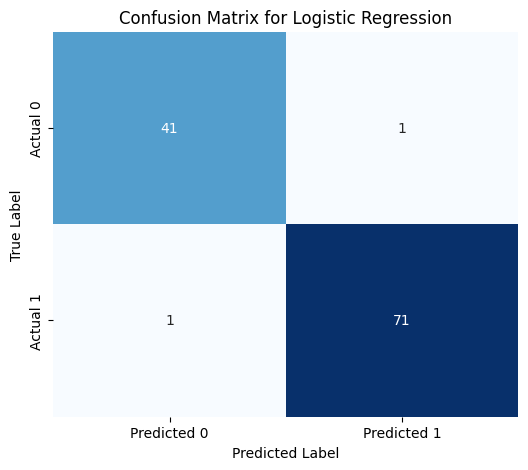

In [34]:
import seaborn as sns

# Get the confusion matrix for the Logistic Regression model
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

## Confusion Matrix Visualization for All Experiments

In [35]:
# Helper function to get predictions for all models under a given experimental setup
def get_model_predictions(X_train_data, y_train_data, X_test_data, y_true_test, models_dict):
    all_predictions = {"y_true": y_true_test}
    for name, model in models_dict.items():
        model.fit(X_train_data, y_train_data)
        y_pred = model.predict(X_test_data)
        try:
            y_prob = model.predict_proba(X_test_data)[:, 1]
        except AttributeError:
            # Some models like SVC with probability=False don't have predict_proba
            y_prob = None
        all_predictions[name] = {"y_pred": y_pred, "y_prob": y_prob}
    return all_predictions

# Get predictions for Original Scaled Data
predictions_original = get_model_predictions(X_train_scaled, y_train, X_test_scaled, y_test, models)

# Get predictions for SMOTE Data
predictions_smote = get_model_predictions(X_train_smote, y_train_smote, X_test_scaled, y_test, models)

# Get predictions for RFE Data
predictions_rfe = get_model_predictions(X_train_rfe, y_train, X_test_rfe, y_test, models)

# Get predictions for SMOTE + RFE Data
predictions_combined = get_model_predictions(X_train_smote_rfe, y_train_smote, X_test_rfe, y_test, models)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:33:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:33:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:33:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:33:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Original Data ---


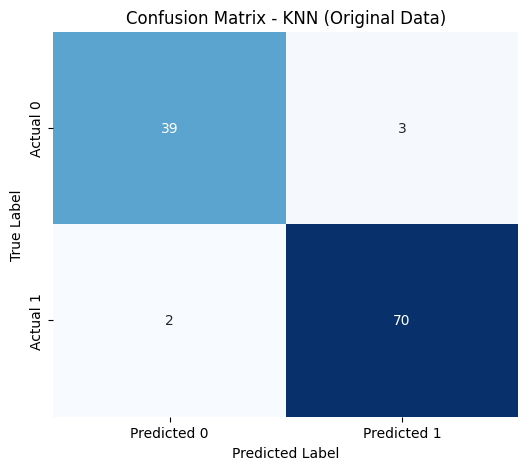

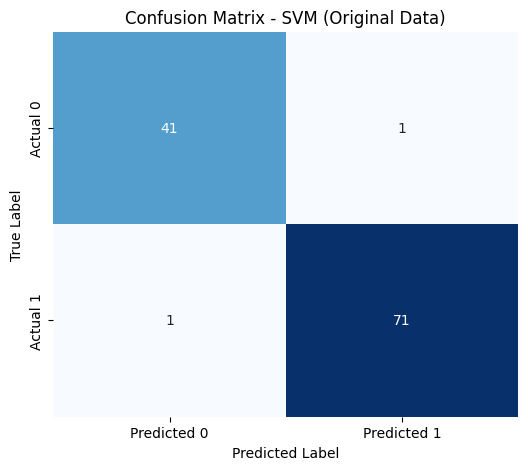

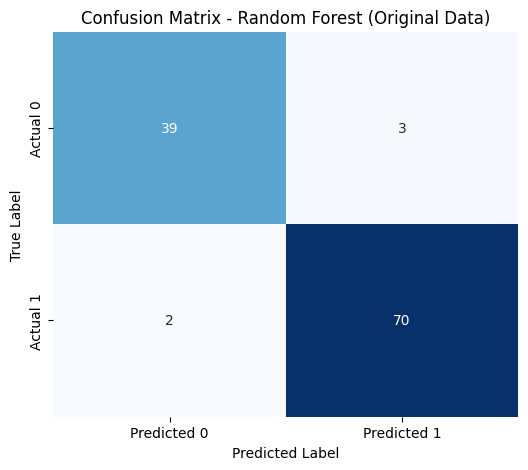

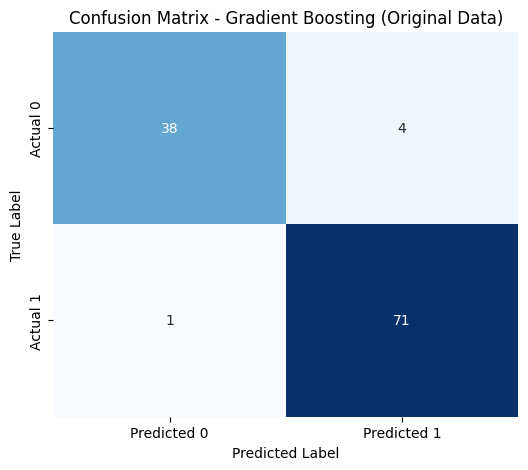

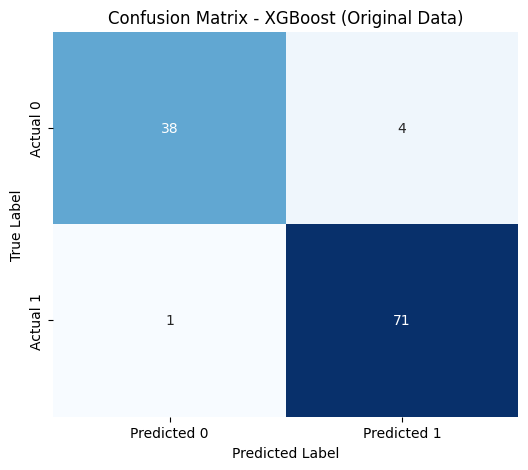


--- SMOTE Data ---


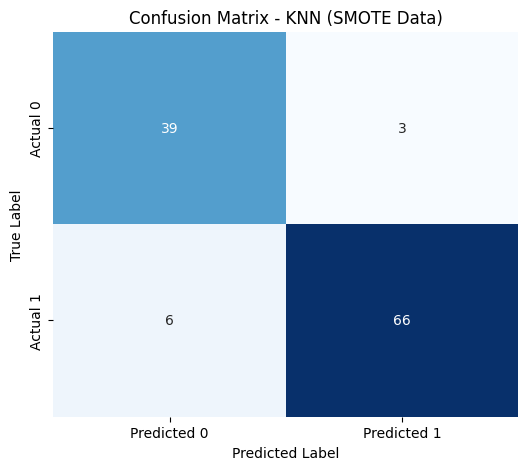

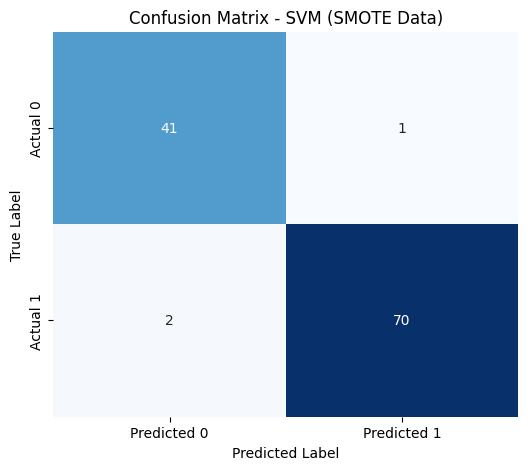

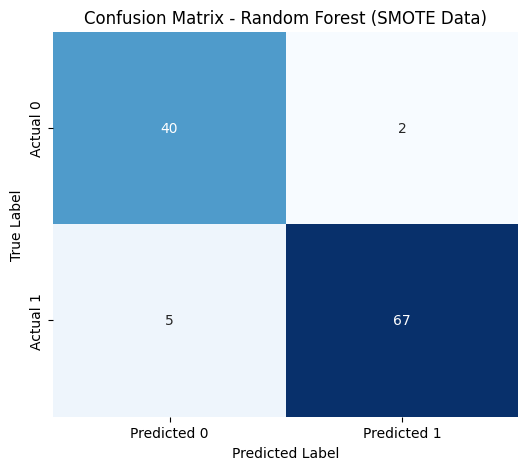

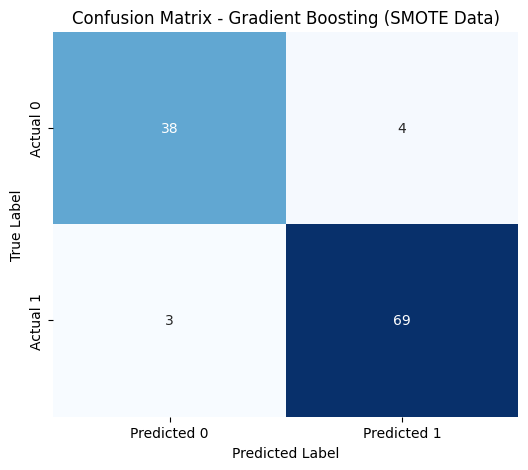

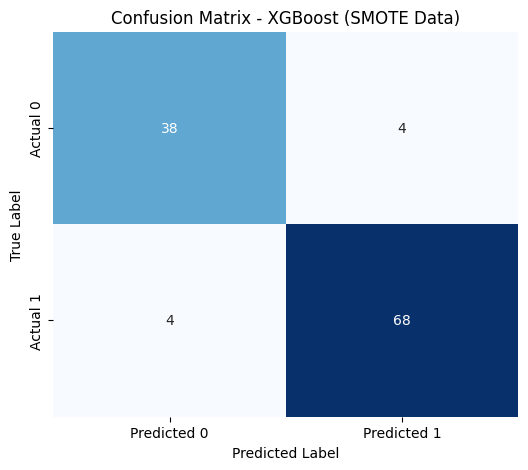


--- RFE Data ---


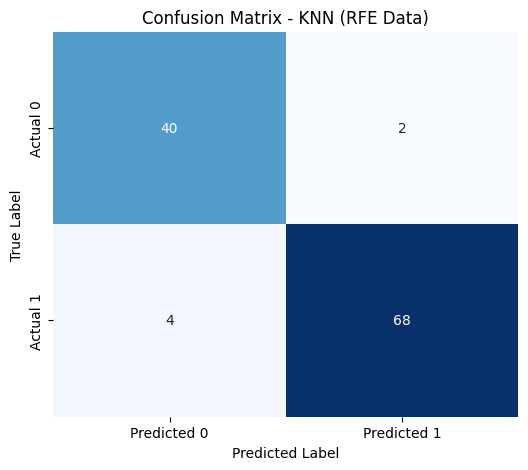

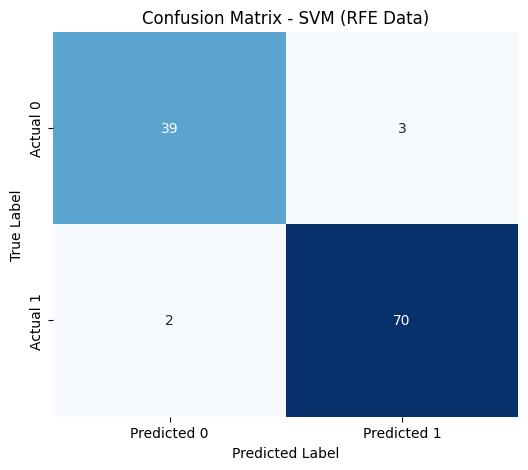

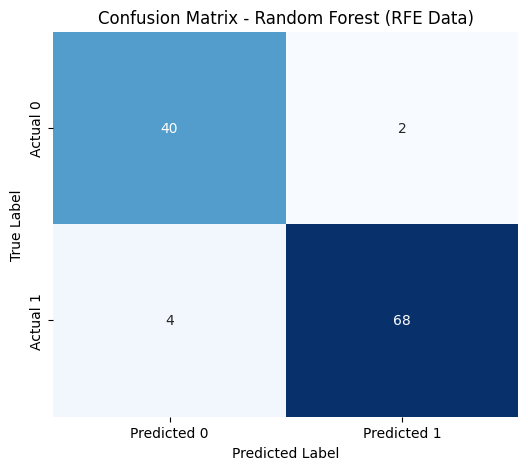

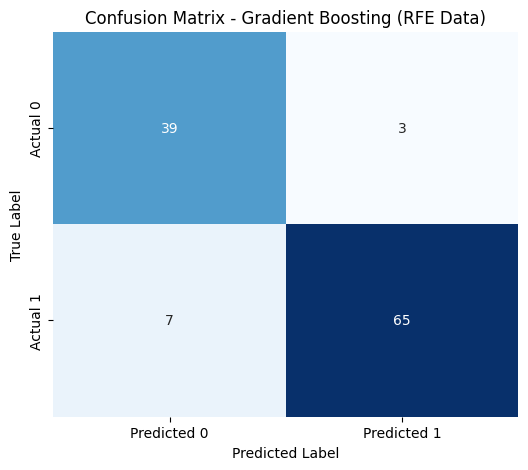

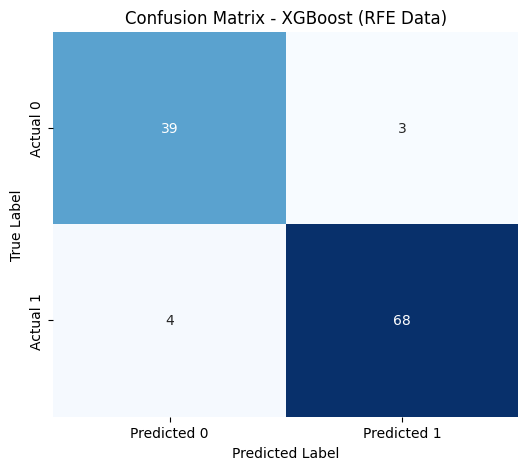


--- SMOTE + RFE Data ---


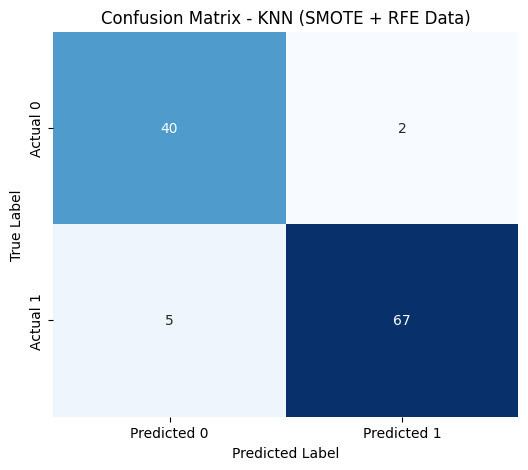

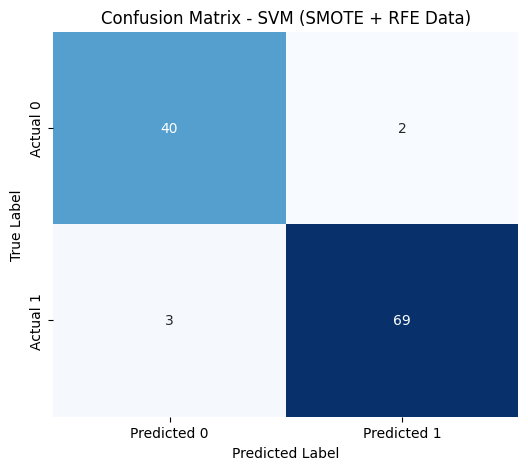

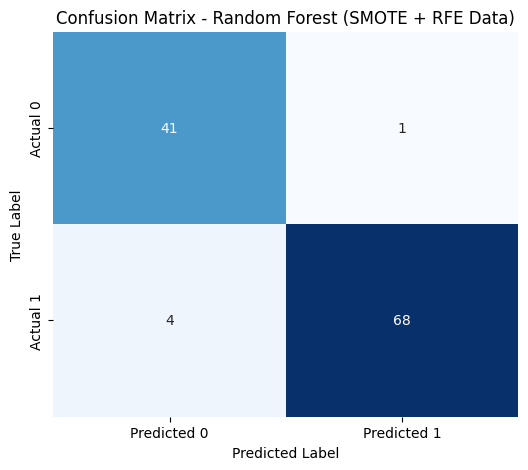

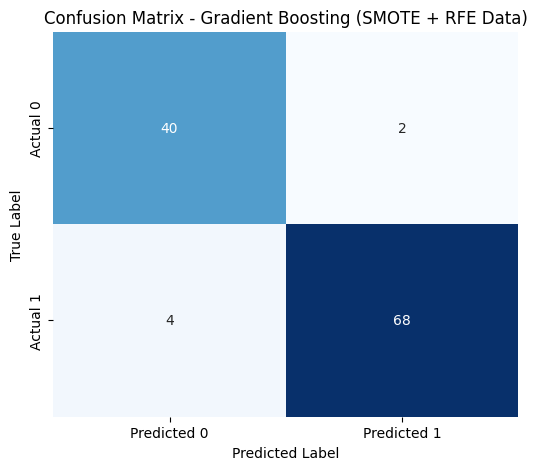

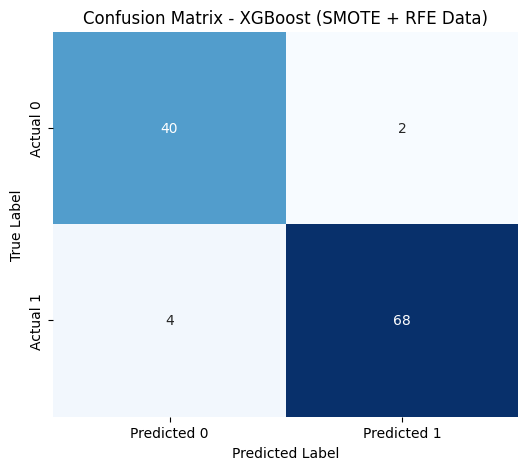

In [36]:
experiments = {
    "Original Data": predictions_original,
    "SMOTE Data": predictions_smote,
    "RFE Data": predictions_rfe,
    "SMOTE + RFE Data": predictions_combined
}

for exp_name, exp_data in experiments.items():
    y_true = exp_data["y_true"]
    print(f"\n--- {exp_name} ---")
    for model_name, preds_data in exp_data.items():
        if model_name == "y_true":
            continue

        y_pred = preds_data["y_pred"]
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Predicted 0', 'Predicted 1'],
                    yticklabels=['Actual 0', 'Actual 1'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {model_name} ({exp_name})')
        plt.show()